In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
test_path = data_path + '/test'
model_path = project_path + '/models/lstm_autoencoder_A8.pt'
results_path = project_path + '/results'

channel = "A-8"

test_data = np.load(
    test_path + "/" + channel + ".npy"
)

test_telemetry = test_data[:, 0]

print("Channel:", channel)
print("Test telemetry shape:", test_telemetry.shape)
print("Model exists:", os.path.exists(model_path))

Mounted at /content/drive
Channel: A-8
Test telemetry shape: (8375,)
Model exists: True


##Recreate the LSTM Autoencoder

Before we can explain the model, we need to recreate the exact same architecture used in SERIAL 23/24.

In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(
        self,
        input_size=1,
        hidden_size=32,
        latent_size=16
    ):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.encoder_fc = nn.Linear(
            hidden_size,
            latent_size
        )

        self.decoder_fc = nn.Linear(
            latent_size,
            hidden_size
        )

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            input_size
        )

    def forward(self, x):
        encoded_sequence, (hidden, cell) = self.encoder(x)

        latent = self.encoder_fc(
            hidden[-1]
        )

        decoder_input = self.decoder_fc(
            latent
        )

        decoder_input = decoder_input.unsqueeze(1)

        decoder_input = decoder_input.repeat(
            1,
            x.size(1),
            1
        )

        decoded_sequence, _ = self.decoder(
            decoder_input
        )

        output = self.output_layer(
            decoded_sequence
        )

        return output


model = LSTMAutoencoder()

print(model)

LSTMAutoencoder(
  (encoder): LSTM(1, 32, batch_first=True)
  (encoder_fc): Linear(in_features=32, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=32, bias=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


###Load the Trained Model

Now we'll load the weights from:

models/lstm_autoencoder_A8.pt

In [ ]:
model.load_state_dict(
    torch.load(
        model_path,
        map_location="cpu"
    )
)

model.eval()

print("LSTM Autoencoder weights loaded successfully.")
print("Model is ready for explanation.")

LSTM Autoencoder weights loaded successfully.
Model is ready for explanation.


##Create Test Windows

Now we need to create the same 50-point time windows used during LSTM training

In [ ]:
window_size = 50

def create_windows(telemetry, window_size=50):
    windows = []

    for i in range(
        len(telemetry) - window_size + 1
    ):
        windows.append(
            telemetry[i:i + window_size]
        )

    return np.array(windows)


test_windows = create_windows(
    test_telemetry,
    window_size
)

X_test = torch.tensor(
    test_windows,
    dtype=torch.float32
).unsqueeze(-1)

print("Window size:", window_size)
print("Test windows shape:", test_windows.shape)
print("Tensor shape:", X_test.shape)

Window size: 50
Test windows shape: (8326, 50)
Tensor shape: torch.Size([8326, 50, 1])


#Calculate Reconstruction Errors

After this, we'll identify the most anomalous windows according to the model and visualize them. That will be the first real XAI step.

In [ ]:
with torch.no_grad():
    reconstructed = model(X_test)

test_errors = torch.mean(
    (X_test - reconstructed) ** 2,
    dim=(1, 2)
).numpy()

print("Reconstruction errors calculated.")
print("Number of window errors:", len(test_errors))
print("Minimum error:", test_errors.min())
print("Maximum error:", test_errors.max())
print("Mean error:", test_errors.mean())
print("Median error:", np.median(test_errors))

Reconstruction errors calculated.
Number of window errors: 8326
Minimum error: 3.5713092e-05
Maximum error: 2.3443575
Mean error: 1.1909478
Median error: 1.556515


##Find the Highest-Error Windows

Now we'll find the windows where the LSTM Autoencoder struggled the most.

In [ ]:
top_n = 10

top_indices = np.argsort(
    test_errors
)[-top_n:][::-1]

top_errors = test_errors[top_indices]

top_results = pd.DataFrame({
    "window_index": top_indices,
    "start_index": top_indices,
    "end_index": top_indices + window_size - 1,
    "reconstruction_error": top_errors
})

print(
    top_results.to_string(index=False)
)

 window_index  start_index  end_index  reconstruction_error
         8107         8107       8156              2.344357
         8106         8106       8155              2.343168
         8108         8108       8157              2.343125
         8109         8109       8158              2.339655
         8105         8105       8154              2.337036
         8110         8110       8159              2.333985
         8104         8104       8153              2.327339
         8111         8111       8160              2.326334
         8112         8112       8161              2.317098
         8103         8103       8152              2.314274


Here we can identify exactly which section of spacecraft telemetry caused the largest reconstruction error.

Then we'll compare those windows with the actual anomaly intervals.

That's where this becomes meaningful XAI rather than simply showing a model score.

##Compare With Ground Truth

NOW We'll create the window-level ground-truth labels and check the top-error windows.

In [ ]:
anomaly_start = 4569
anomaly_end = 8374

window_ground_truth = np.zeros(
    len(test_windows),
    dtype=int
)

for i in range(len(test_windows)):
    window_start = i
    window_end = i + window_size - 1

    # Mark window anomalous if it overlaps the anomaly interval
    if (
        window_end >= anomaly_start
        and window_start <= anomaly_end
    ):
        window_ground_truth[i] = 1


top_results["ground_truth_anomaly"] = [
    window_ground_truth[i]
    for i in top_indices
]

print(
    top_results.to_string(index=False)
)

print("\nTop-error windows that overlap the ground-truth anomaly:")
print(
    top_results["ground_truth_anomaly"].sum(),
    "out of",
    top_n
)

 window_index  start_index  end_index  reconstruction_error  ground_truth_anomaly
         8107         8107       8156              2.344357                     1
         8106         8106       8155              2.343168                     1
         8108         8108       8157              2.343125                     1
         8109         8109       8158              2.339655                     1
         8105         8105       8154              2.337036                     1
         8110         8110       8159              2.333985                     1
         8104         8104       8153              2.327339                     1
         8111         8111       8160              2.326334                     1
         8112         8112       8161              2.317098                     1
         8103         8103       8152              2.314274                     1

Top-error windows that overlap the ground-truth anomaly:
10 out of 10


| Finding                            |    Result |
| ---------------------------------- | --------: |
| Highest-error window               | 8107–8156 |
| Highest reconstruction error       |  2.344357 |
| Top 10 windows overlapping anomaly | **10/10** |
| Ground-truth anomaly interval      | 4569–8374 |


What does this tell us?

It tells us that at least in this part of A-8, the LSTM Autoencoder's reconstruction error is identifying behavior inside the labeled anomaly region.

However, we should not conclude that the model is fully successful yet. Earlier, we saw that the overall reconstruction error was actually higher in the labeled normal region than in the anomaly region.

###Find the Most Important Timesteps

In [ ]:
# Calculate reconstruction error for each timestep
timestep_errors = torch.mean(
    (X_test - reconstructed) ** 2,
    dim=2
).numpy()

selected_window = 8107

selected_errors = timestep_errors[selected_window]

top_timestep_indices = np.argsort(
    selected_errors
)[-10:][::-1]

timestep_results = pd.DataFrame({
    "relative_timestep": top_timestep_indices,
    "absolute_index": selected_window + top_timestep_indices,
    "timestep_error": selected_errors[top_timestep_indices]
})

print(timestep_results.to_string(index=False))

 relative_timestep  absolute_index  timestep_error
                20            8127        3.437180
                19            8126        3.436839
                21            8128        3.435840
                18            8125        3.435399
                17            8124        3.433264
                22            8129        3.432048
                16            8123        3.430681
                15            8122        3.427763
                14            8121        3.424511
                13            8120        3.420847


we now have a useful explanation chain:

LSTM Autoencoder → high reconstruction error at window 8107–8156 → strongest reconstruction errors around timesteps 8120–8129 → these timesteps fall inside the labeled anomaly region.

##Visualize the Explanation

figure showing:

Actual telemetry

Reconstructed telemetry

Reconstruction error

The important region around 8120–8129

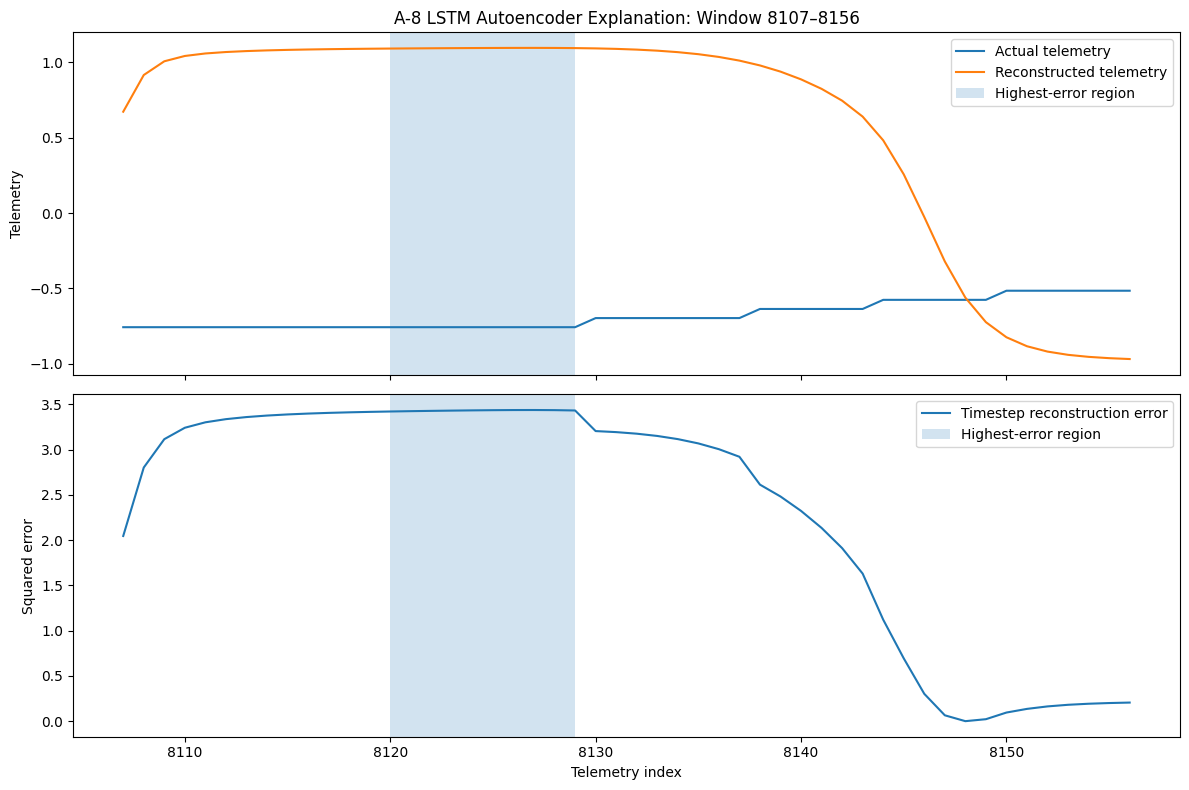

In [ ]:
selected_window = 8107

actual_window = X_test[selected_window].squeeze().numpy()
reconstructed_window = reconstructed[selected_window].squeeze().numpy()
error_window = timestep_errors[selected_window]

absolute_indices = np.arange(
    selected_window,
    selected_window + window_size
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

axes[0].plot(
    absolute_indices,
    actual_window,
    label="Actual telemetry"
)

axes[0].plot(
    absolute_indices,
    reconstructed_window,
    label="Reconstructed telemetry"
)

axes[0].axvspan(
    8120,
    8129,
    alpha=0.2,
    label="Highest-error region"
)

axes[0].set_ylabel("Telemetry")
axes[0].set_title("A-8 LSTM Autoencoder Explanation: Window 8107–8156")
axes[0].legend()

axes[1].plot(
    absolute_indices,
    error_window,
    label="Timestep reconstruction error"
)

axes[1].axvspan(
    8120,
    8129,
    alpha=0.2,
    label="Highest-error region"
)

axes[1].set_xlabel("Telemetry index")
axes[1].set_ylabel("Squared error")
axes[1].legend()

plt.tight_layout()
plt.show()

The visualization clearly shows:

Actual telemetry is around −0.75 while the reconstruction is around +1.0.
This creates a very large reconstruction error.
The largest timestep errors occur around 8120–8129.
The error falls when the reconstructed signal moves closer to the actual signal.
These points are inside the ground-truth anomaly interval 4569–8374.

So we can safely say:

The LSTM Autoencoder assigns a high anomaly score to this region because its reconstruction differs substantially from the observed telemetry.

We now have three levels of explanation:

Level 1 — Window

Window 8107–8156 has very high reconstruction error.

Level 2 — Ground truth

This window overlaps the labeled anomaly interval.

Level 3 — Timestep

Within the window, indices approximately 8120–8129 contribute the largest reconstruction errors.

This is a good simple XAI approach for an autoencoder because we're explaining the reconstruction error itself, rather than adding SHAP just because it is popular

##Explain the Top 10 High-Error Windows

Now we will check whether the same pattern appears across the top 10 highest-error windows, instead of relying on only window 8107.

In [ ]:
top_window_explanations = []

for window_index in top_indices:

    window_errors = timestep_errors[window_index]

    top_local_index = np.argmax(window_errors)

    absolute_index = window_index + top_local_index

    top_window_explanations.append({
        "window_index": window_index,
        "window_start": window_index,
        "window_end": window_index + window_size - 1,
        "highest_error_index": absolute_index,
        "highest_timestep_error": window_errors[top_local_index]
    })

top_window_explanations = pd.DataFrame(
    top_window_explanations
)

print(
    top_window_explanations.to_string(index=False)
)

 window_index  window_start  window_end  highest_error_index  highest_timestep_error
         8107          8107        8156                 8127                3.437180
         8106          8106        8155                 8125                3.441368
         8108          8108        8157                 8128                3.433458
         8109          8109        8158                 8129                3.430052
         8105          8105        8154                 8124                3.445832
         8110          8110        8159                 8129                3.425558
         8104          8104        8153                 8123                3.450630
         8111          8111        8160                 8129                3.420072
         8112          8112        8161                 8129                3.414255
         8103          8103        8152                 8121                3.456156


statement for your paper is:

The timestep-level explanation showed that the largest reconstruction errors across the ten highest-error windows were consistently concentrated around telemetry indices 8121–8129. This indicates that the model's high anomaly score was driven primarily by a localized region of the telemetry sequence rather than being uniformly distributed across the window.

And we can add:

All ten high-error windows overlapped the ground-truth anomaly interval (4569–8374), providing evidence that the highlighted region corresponds to the labeled anomalous period.

#Save the XAI Results

In [ ]:
explanation_path = (
    results_path +
    "/xai_top_window_explanations_A8.csv"
)

top_window_explanations.to_csv(
    explanation_path,
    index=False
)

print("XAI results saved to:")
print(explanation_path)

XAI results saved to:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/xai_top_window_explanations_A8.csv


##Final XAI Visualization

This final figure will show the whole A-8 test sequence, the LSTM reconstruction error, the ground-truth anomaly region, and the region where the model produced its strongest errors.


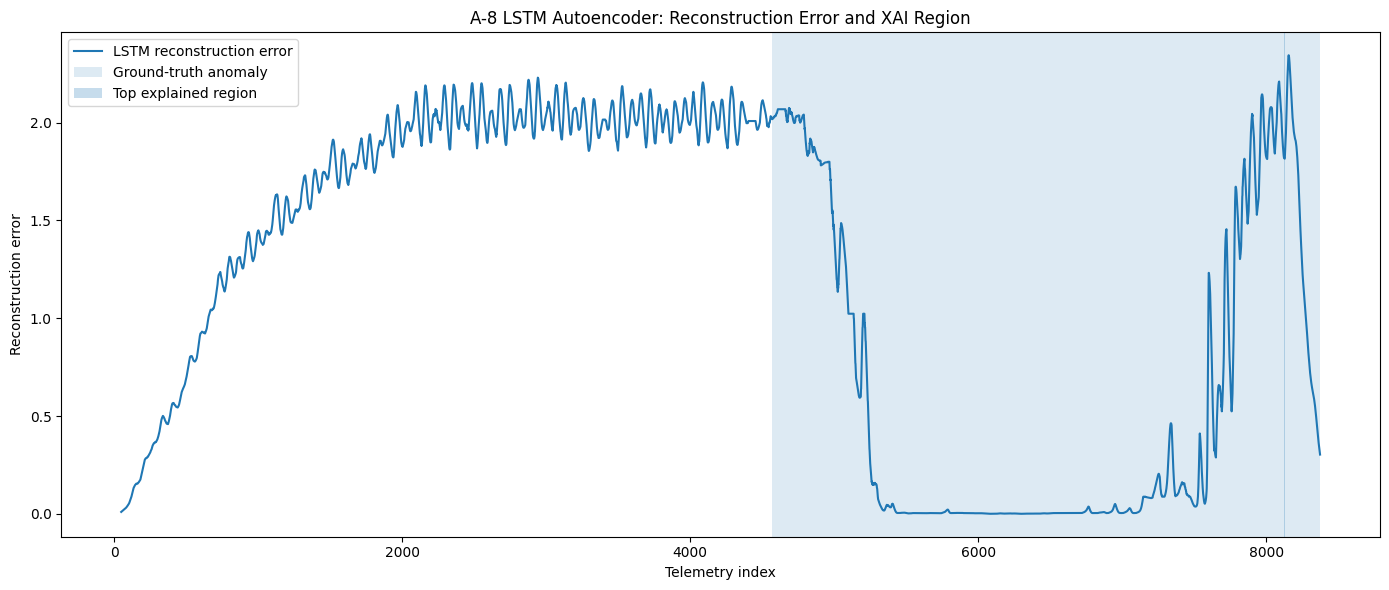

In [ ]:
anomaly_start = 4569
anomaly_end = 8374

window_indices = np.arange(
    window_size - 1,
    len(test_telemetry)
)

plt.figure(figsize=(14, 6))

plt.plot(
    window_indices,
    test_errors,
    label="LSTM reconstruction error"
)

plt.axvspan(
    anomaly_start,
    anomaly_end,
    alpha=0.15,
    label="Ground-truth anomaly"
)

plt.axvspan(
    8121,
    8129,
    alpha=0.25,
    label="Top explained region"
)

plt.xlabel("Telemetry index")
plt.ylabel("Reconstruction error")
plt.title("A-8 LSTM Autoencoder: Reconstruction Error and XAI Region")
plt.legend()

plt.tight_layout()
plt.show()

The explainability analysis demonstrated that the LSTM Autoencoder's highest reconstruction errors were concentrated around telemetry indices 8121–8129, which lie within the labeled anomaly interval. However, substantial reconstruction errors were also observed in the preceding normal region, while large portions of the labeled anomaly period produced relatively low reconstruction errors. These findings indicate that the model's reconstruction error provides localized explanations for its anomaly scores but does not consistently align with the ground-truth anomaly labels.

##Verify the XAI Files

In [ ]:
xai_file = (
    project_path +
    "/results/xai_top_window_explanations_A8.csv"
)

print("File exists:", os.path.exists(xai_file))

if os.path.exists(xai_file):
    xai_check = pd.read_csv(xai_file)

    print("\nRows:", len(xai_check))
    print("\nColumns:")
    print(xai_check.columns.tolist())

    print("\nSaved XAI results:")
    print(xai_check.to_string(index=False))

File exists: True

Rows: 10

Columns:
['window_index', 'window_start', 'window_end', 'highest_error_index', 'highest_timestep_error']

Saved XAI results:
 window_index  window_start  window_end  highest_error_index  highest_timestep_error
         8107          8107        8156                 8127                3.437180
         8106          8106        8155                 8125                3.441368
         8108          8108        8157                 8128                3.433458
         8109          8109        8158                 8129                3.430052
         8105          8105        8154                 8124                3.445832
         8110          8110        8159                 8129                3.425558
         8104          8104        8153                 8123                3.450630
         8111          8111        8160                 8129                3.420072
         8112          8112        8161                 8129                3.414

The XAI analysis shows that the model's largest reconstruction errors are localized around indices 8121–8129, and this region is inside the labeled anomaly interval. However, the model also produces high reconstruction errors in the labeled normal region and low errors during substantial parts of the anomaly.

So our conclusion is:

The XAI method successfully identifies which telemetry region drives the model's anomaly score, while also revealing that the current LSTM Autoencoder does not consistently distinguish anomalous behavior from normal behavior on A-8.

##commit github

In [ ]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status --short

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (48/48), done.
 M notebooks/13_evaluate_global_zscore.ipynb
 M notebooks/14_rolling_zscore.ipynb
 M notebooks/15_compare_statistical_methods.ipynb
 M notebooks/16_isolation_forest.ipynb
 M notebooks/17_evaluate_isolation_forest.ipynb
 M notebooks/18_one_class_svm.ipynb
 M notebooks/19_compare_classical_methods.ipynb
 M notebooks/20_autoencoder.ipynb
 M notebooks/21_analyze_autoencoder.ipynb
 M notebooks/22_time_series_windows.ipynb
 M notebooks/23_lstm_autoencoder.ipynb
 M notebooks/24_evaluate_lstm_autoencoder.ipynb
 M notebooks/25_model_comparison_and_research_gap.ipynb
?? notebooks/26_explainable_ai.ipynb
?? results/xai_top_window_explanations_A8.csv


In [ ]:
!git add notebooks/26_explainable_ai.ipynb
!git add results/xai_top_window_explanations_A8.csv

!git status --short

 M notebooks/13_evaluate_global_zscore.ipynb
 M notebooks/14_rolling_zscore.ipynb
 M notebooks/15_compare_statistical_methods.ipynb
 M notebooks/16_isolation_forest.ipynb
 M notebooks/17_evaluate_isolation_forest.ipynb
 M notebooks/18_one_class_svm.ipynb
 M notebooks/19_compare_classical_methods.ipynb
 M notebooks/20_autoencoder.ipynb
 M notebooks/21_analyze_autoencoder.ipynb
 M notebooks/22_time_series_windows.ipynb
 M notebooks/23_lstm_autoencoder.ipynb
 M notebooks/24_evaluate_lstm_autoencoder.ipynb
 M notebooks/25_model_comparison_and_research_gap.ipynb
A  notebooks/26_explainable_ai.ipynb
A  results/xai_top_window_explanations_A8.csv


In [ ]:
!git commit -m "Complete SERIAL 26 explainable AI"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@5ff01cce807e.(none)')


In [ ]:
!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

!git config --global user.name
!git config --global user.email

Amit Chandra Das
arickroy0@gmail.com


In [ ]:
!git commit -m "Complete SERIAL 26 explainable AI"

[main 807b7a5] Complete SERIAL 26 explainable AI
 2 files changed, 12 insertions(+)
 create mode 100644 notebooks/26_explainable_ai.ipynb
 create mode 100644 results/xai_top_window_explanations_A8.csv


In [ ]:
!git push origin main

Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 70.88 KiB | 5.45 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   d8453e2..807b7a5  main -> main
